### PCA from full.csv

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df_pca = pd.read_csv('../dataset/pca_transformed_data.csv')
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC62,PC63,PC64,PC65,PC66,PC67,PC68,PC69,Activity,Subject
0,-5.537858,0.716345,1.412546,-1.733302,-0.920246,0.467883,-0.196259,0.845865,-1.324194,0.181811,...,0.033817,0.244868,-0.143596,0.869081,-0.284947,-0.074658,-0.326752,-0.172623,STANDING,1
1,-5.564174,0.579506,1.827912,-0.796021,-0.626565,-0.991651,-0.065073,-0.758446,-0.944750,-0.570210,...,0.099989,-0.206491,-0.089866,0.323476,0.293009,-0.040302,0.233337,0.053142,STANDING,1
2,-5.499319,0.297684,2.148152,-0.604225,-0.005493,0.026151,-0.018304,0.084837,-0.219448,-0.216676,...,-0.121519,-0.429030,-0.138414,0.055320,-0.144269,0.297424,0.207496,-0.032137,STANDING,1
3,-5.700396,-0.354586,2.149211,-0.328516,-0.791819,-0.898207,-0.690719,-0.469168,0.390371,0.247483,...,-0.380796,-0.245556,-0.089829,-0.225721,0.094742,0.417312,0.484095,0.020119,STANDING,1
4,-5.769082,-0.559389,2.365302,-0.333767,-0.448452,-0.328038,-0.252560,-0.044749,0.424875,0.254294,...,0.213089,-0.001096,-0.006260,-0.227487,0.322568,0.165876,-0.079276,-0.141462,STANDING,1


In [9]:
X = df_pca[[f"PC{i}" for i in range(1, 70)]]  # Predictors (69 components)
y = df_pca["Activity"]                        # Target variable
groups = df_pca["Subject"]

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

# Get indices for train and test sets based on Subject groups
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

train_subjects = sorted(groups_train.unique())
test_subjects = sorted(groups_test.unique())

print("Subjects in training data:")
print(train_subjects)

print("\nSubjects in test data:")
print(test_subjects)

print("\nNumber of training subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))

overlap = set(train_subjects) & set(test_subjects)
print("\nOverlapping subjects:", overlap)

In [11]:
# Initialize and train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate on unseen subjects
y_pred = model.predict(X_test)

print("--- Classification Report (Unseen Subjects) ---")
print(classification_report(y_test, y_pred))

--- Classification Report (Unseen Subjects) ---
                    precision    recall  f1-score   support

            LAYING       0.99      0.99      0.99       537
           SITTING       0.75      0.80      0.78       495
          STANDING       0.81      0.76      0.78       527
           WALKING       0.95      0.93      0.94       451
WALKING_DOWNSTAIRS       0.96      0.70      0.81       389
  WALKING_UPSTAIRS       0.78      0.99      0.87       429

          accuracy                           0.86      2828
         macro avg       0.87      0.86      0.86      2828
      weighted avg       0.87      0.86      0.86      2828



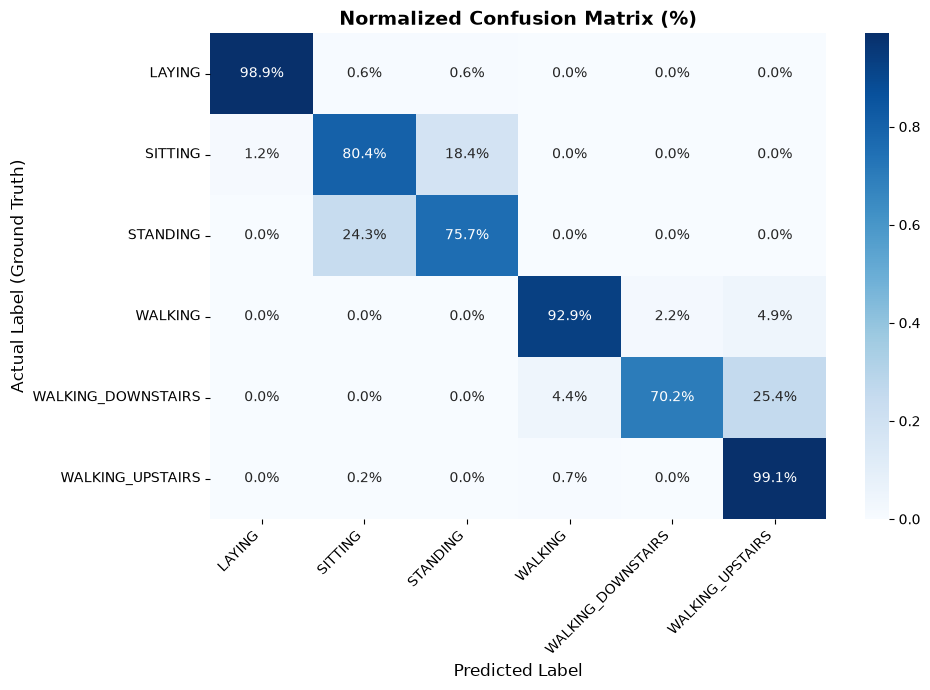

In [12]:
# Compute normalized matrix (percentages along rows)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# 2. Get unique activity labels in alphabetical order (matching confusion_matrix default)
labels = sorted(y_test.unique())

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%',              # Format as percentage (e.g., 70.2%)
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()